# The encoder for general $m$

Same three steps as [encode.ipynb](encode.ipynb), but Reed--Solomon runs over
$\mathbb{F}_{p^m}$ instead of $\mathbb{F}_p$. Every function takes `p, m` and returns
plain numpy arrays, exactly like `encode.ipynb` -- set `m = 1` and you get that notebook
back.

What changes: $N = p^m$ (not $p$), the hypervector has dimension $p^{2m}$ (not $p^2$),
and field arithmetic needs lookup tables instead of `% p`.

What does not: $\phi$ is untouched, and every figure of merit is a function of $N$ alone,
so $d_{\min} = N-K+1$, $\mu = (K-1)/N$ and $l_{\max}$ carry over unchanged.

In [1]:
import numpy as np
from itertools import product

import matplotlib as mpl
import matplotlib.pyplot as plt
from sympy import primerange

%matplotlib inline
np.set_printoptions(precision=3, suppress=True, linewidth=120)

# Step 1 - phi (unchanged from encode.ipynb)

In [2]:
def phi(a, p):
    """Map field elements to roots of unity"""
    a = np.asarray(a)
    return np.exp(2j * np.pi * a / p)


p, m = 2, 3
print(f"phi over F_{p} is =")
for a in range(p):
    print(f"phi({a}) = {phi(a, p): .3f}")
print("\np = 2 makes phi real, so hypervectors are +/-1 vectors")

phi over F_2 is =
phi(0) =  1.000+0.000j
phi(1) = -1.000+0.000j

p = 2 makes phi real, so hypervectors are +/-1 vectors


# Step 2 - the field $\mathbb{F}_{p^m}$

This is the only genuinely new part. $\mathbb{F}_{p^m}$ is $\mathbb{F}_p[x]/(f)$ for a
monic irreducible $f$ of degree $m$. An element is stored as a plain integer
$0..p^m-1$ whose base-$p$ digits are its polynomial coefficients.

`gf_tables` returns three arrays and nothing else:

- `vec[a]` -- the base-$p$ digit vector of `a`, the paper's "represented as a vector in
  $\mathbb{F}_p^m$"
- `ADD[a, b]`, `MUL[a, b]` -- the field operations

At $m = 1$ these degenerate to `vec[a] == [a]`, `ADD == (a+b) % p`, `MUL == a*b % p`,
which is why `encode.ipynb` never needed them.

In [3]:
def poly_mod(a, f, p):
    """Remainder of a mod monic f, over F_p. Coefficients low -> high."""
    a = [x % p for x in a]
    df = len(f) - 1
    for i in range(len(a) - 1, df - 1, -1):
        c = a[i]
        if c:
            for j in range(df + 1):
                a[i - df + j] = (a[i - df + j] - c * f[j]) % p
    return a[:df]


def poly_mul(a, b, p):
    out = [0] * (len(a) + len(b) - 1)
    for i, ai in enumerate(a):
        for j, bj in enumerate(b):
            out[i + j] = (out[i + j] + ai * bj) % p
    return out


def is_irreducible(f, p):
    """Monic f is irreducible iff no monic g with 1 <= deg g <= deg f / 2 divides it."""
    d_f = len(f) - 1
    if d_f <= 1:
        return True
    for d in range(1, d_f // 2 + 1):
        for tail in product(range(p), repeat=d):
            if not any(poly_mod(list(f), list(tail) + [1], p)):
                return False
    return True


def find_irreducible(p, m):
    """The first monic irreducible of degree m over F_p."""
    for tail in product(range(p), repeat=m):
        f = list(tail) + [1]
        if is_irreducible(f, p):
            return f
    raise ValueError(f"no irreducible polynomial of degree {m} over F_{p}")

In [4]:
def gf_tables(p, m):
    """F_{p^m} as F_p[x]/(f).  Returns (vec, ADD, MUL)."""
    q = p ** m
    f = find_irreducible(p, m)
    pw = p ** np.arange(m)
    vec = np.array([[(a // p ** k) % p for k in range(m)] for a in range(q)], dtype=int)

    ADD = ((vec[:, None, :] + vec[None, :, :]) % p) @ pw          # vectorized
    MUL = np.zeros((q, q), dtype=int)
    for a in range(q):
        for b in range(q):
            prod = poly_mod(poly_mul(list(vec[a]), list(vec[b]), p), f, p)
            MUL[a, b] = int(np.array(prod) @ pw)
    return vec, ADD, MUL


p, m = 2, 3
vec, ADD, MUL = gf_tables(p, m)
q = p ** m
print(f"F_{p}^{m}: modulus f(x) = {find_irreducible(p, m)} (coefficients low -> high)")
print(f"element 5 <-> digit vector {vec[5]}")
print(f"\nADD (note F_2^3 addition is XOR, NOT (a+b) % 8):\n{ADD}")
print(f"\nMUL:\n{MUL}")

# it is a field
assert (ADD[0] == np.arange(q)).all(), "0 is not the additive identity"
assert (MUL[1] == np.arange(q)).all(), "1 is not the multiplicative identity"
assert (ADD == ADD.T).all() and (MUL == MUL.T).all()
for a in range(1, q):
    assert sorted(MUL[a]) == list(range(q)), f"{a} has no inverse"
print(f"\nF_{p}^{m} verified: commutative, unital, every nonzero element invertible")

# at m = 1 it collapses to plain mod-p arithmetic
for _p in (3, 5, 7):
    _v, _A, _M = gf_tables(_p, 1)
    assert (_v.ravel() == np.arange(_p)).all()
    assert (_A == (np.arange(_p)[:, None] + np.arange(_p)) % _p).all()
    assert (_M == (np.arange(_p)[:, None] * np.arange(_p)) % _p).all()
print("at m = 1 the tables are just (a+b) % p and a*b % p")

F_2^3: modulus f(x) = [1, 0, 1, 1] (coefficients low -> high)
element 5 <-> digit vector [1 0 1]

ADD (note F_2^3 addition is XOR, NOT (a+b) % 8):
[[0 1 2 3 4 5 6 7]
 [1 0 3 2 5 4 7 6]
 [2 3 0 1 6 7 4 5]
 [3 2 1 0 7 6 5 4]
 [4 5 6 7 0 1 2 3]
 [5 4 7 6 1 0 3 2]
 [6 7 4 5 2 3 0 1]
 [7 6 5 4 3 2 1 0]]

MUL:
[[0 0 0 0 0 0 0 0]
 [0 1 2 3 4 5 6 7]
 [0 2 4 6 5 7 1 3]
 [0 3 6 5 1 2 7 4]
 [0 4 5 1 7 3 2 6]
 [0 5 7 2 3 6 4 1]
 [0 6 1 7 2 4 3 5]
 [0 7 3 4 6 1 5 2]]

F_2^3 verified: commutative, unital, every nonzero element invertible
at m = 1 the tables are just (a+b) % p and a*b % p


# Step 3 - The outer code: Reed Solomon over $\mathbb{F}_{p^m}$

Same polynomial-evaluation code as `encode.ipynb`, with three substitutions:
evaluation points are all $N = p^m$ field elements, the powers $\beta^i$ are built with
`MUL`, and the accumulation uses `ADD`. None of it can be written with `%`.

`tables` is an optional argument so the sweeps further down can build the tables once
instead of per call.

In [5]:
def reed_solomon_encode(message, p, m, tables=None):
    """message: length-K coefficients over F_{p^m}. Returns length-N=p^m codeword"""
    vec, ADD, MUL = gf_tables(p, m) if tables is None else tables
    N = p ** m
    points = np.arange(N)
    c = np.zeros(N, dtype=int)
    power = np.ones(N, dtype=int)                  # beta^0; the field one is the integer 1
    for a in message:
        c = ADD[c, MUL[int(a), power]]
        power = MUL[power, points]                 # beta^i -> beta^(i+1)
    return c


p, m = 2, 3
message = [2, 1]
print(f"message (coeffs): {message}   over F_{p}^{m}, N = {p ** m}")
print("codeword f(0...7):", reed_solomon_encode(message, p, m))

# some examples
for msg in [[2, 1], [1, 2], [3, 4]]:
    print(f"   {msg} -> {reed_solomon_encode(msg, p, m)}")

# it is linear over the field, which is what makes binding work later
_v, _A, _M = gf_tables(p, m)
_rng = np.random.default_rng(0)
for _ in range(20):
    u = [int(x) for x in _rng.integers(0, p ** m, 2)]
    v = [int(x) for x in _rng.integers(0, p ** m, 2)]
    w = [int(_A[a, b]) for a, b in zip(u, v)]
    assert (reed_solomon_encode(w, p, m) ==
            _A[reed_solomon_encode(u, p, m), reed_solomon_encode(v, p, m)]).all()
print("\nRS is linear over F_{p^m}")

# at m = 1 it matches encode.ipynb's integer Vandermonde exactly
for _p, _K in [(5, 2), (7, 2), (11, 3)]:
    for _ in range(10):
        u = [int(x) for x in _rng.integers(0, _p, _K)]
        powers = np.arange(_p)[:, None] ** np.arange(_K)
        assert (reed_solomon_encode(u, _p, 1) == (powers @ u) % _p).all()
print("at m = 1 it reproduces encode.ipynb's (powers @ message) % p")

message (coeffs): [2, 1]   over F_2^3, N = 8
codeword f(0...7): [2 3 0 1 6 7 4 5]
   [2, 1] -> [2 3 0 1 6 7 4 5]
   [1, 2] -> [1 3 5 7 4 6 0 2]
   [3, 4] -> [3 7 6 2 4 0 1 5]

RS is linear over F_{p^m}
at m = 1 it reproduces encode.ipynb's (powers @ message) % p


## point wise distance demo

Distinct codewords agree in at most $K-1$ places, so $d_{\min} = N - K + 1$. Same
Singleton bound as at $m = 1$, now with $N = p^m$.

In [6]:
p, m, K = 2, 3, 2
q = p ** m
tab = gf_tables(p, m)

codewords = {msg: tuple(int(x) for x in reed_solomon_encode(msg, p, m, tab))
             for msg in product(range(q), repeat=K)}

max_agreement = 0
msgs = list(codewords)
for i in range(len(msgs)):
    for j in range(i + 1, len(msgs)):
        agree = sum(x == y for x, y in zip(codewords[msgs[i]], codewords[msgs[j]]))
        max_agreement = max(max_agreement, agree)

print(f"F_{p}^{m}, K = {K}:  N = {q}")
print(f"Total distinct codewords: {len(set(codewords.values()))} (= q^K = {q ** K})")
print(f"Max positions two codewords agree on: {max_agreement} (<= K-1 = {K - 1})")
print(f"so d_min = N - K + 1 = {q - K + 1}")

F_2^3, K = 2:  N = 8
Total distinct codewords: 64 (= q^K = 64)
Max positions two codewords agree on: 1 (<= K-1 = 1)
so d_min = N - K + 1 = 7


# Step 4 - Hadamard (inner code)

One trap here. The paper defines $f_{\mathrm{Had}}(a) = (ab^\top)_{b}$, and that
$ab^\top$ is the **dot product of the digit vectors mod $p$** -- not `MUL`. At $m = 1$
the two happen to coincide, which is why `encode.ipynb`'s `np.outer(idx, idx) % p` works
there and why using `MUL` here would look right and be wrong.

In [7]:
def hadamard_exponents(p, m, tables=None):
    """L[b, a] = <vec(a), vec(b)> mod p -- a dot product, NOT MUL."""
    vec, ADD, MUL = gf_tables(p, m) if tables is None else tables
    return (vec @ vec.T) % p


def hadamard_matrix(p, m, tables=None):
    """f_Had after phi. Column a is phi(f_Had(a))."""
    return phi(hadamard_exponents(p, m, tables), p)


p, m = 2, 3
print(f"f_Had exponents before phi (dot product of digit vectors mod {p}):")
print(hadamard_exponents(p, m))
print(f"\nMUL, for comparison -- NOT the same matrix:")
print(gf_tables(p, m)[2])

# m = 1: dot product == MUL, which is why encode.ipynb gets away with outer()
for _p in (2, 3, 5, 7):
    idx = np.arange(_p)
    assert (hadamard_exponents(_p, 1) == np.outer(idx, idx) % _p).all()
print("\nm = 1: exponents == np.outer(idx, idx) % p, encode.ipynb's version")

# m > 1: they differ, every time
for _p, _m in [(2, 2), (2, 3), (2, 4), (3, 2), (5, 2)]:
    assert not (hadamard_exponents(_p, _m) == gf_tables(_p, _m)[2]).all()
print("m > 1: exponents != MUL, so using MUL would silently break the inner code")

# H is still a Hadamard matrix
for _p, _m in [(2, 3), (3, 2), (5, 1)]:
    H = hadamard_matrix(_p, _m)
    N = _p ** _m
    assert np.allclose(H.conj().T @ H, N * np.eye(N)), f"H^dag H != N I at p={_p}, m={_m}"
print("H^dagger H = N I for (p, m) = (2, 3), (3, 2), (5, 1)")

f_Had exponents before phi (dot product of digit vectors mod 2):
[[0 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 0 1]
 [0 0 1 1 0 0 1 1]
 [0 1 1 0 0 1 1 0]
 [0 0 0 0 1 1 1 1]
 [0 1 0 1 1 0 1 0]
 [0 0 1 1 1 1 0 0]
 [0 1 1 0 1 0 0 1]]

MUL, for comparison -- NOT the same matrix:
[[0 0 0 0 0 0 0 0]
 [0 1 2 3 4 5 6 7]
 [0 2 4 6 5 7 1 3]
 [0 3 6 5 1 2 7 4]
 [0 4 5 1 7 3 2 6]
 [0 5 7 2 3 6 4 1]
 [0 6 1 7 2 4 3 5]
 [0 7 3 4 6 1 5 2]]

m = 1: exponents == np.outer(idx, idx) % p, encode.ipynb's version
m > 1: exponents != MUL, so using MUL would silently break the inner code
H^dagger H = N I for (p, m) = (2, 3), (3, 2), (5, 1)


# Step 5 - Concatenate

In [8]:
def histo_encode(message, p, m, tables=None):
    """The histo paper encoding function, general m.
    message: length-K list/array of field symbols in {0,...,p^m-1}
    returns: complex hypervector of dimension p^(2m)"""
    tables = gf_tables(p, m) if tables is None else tables
    codeword = reed_solomon_encode(message, p, m, tables)
    H = hadamard_matrix(p, m, tables)
    blocks = H[:, codeword].T
    return blocks.reshape(-1)                       # flatten to 1D array


p, m = 2, 3
message = [2, 1]
codeword = reed_solomon_encode(message, p, m)
hv = histo_encode(message, p, m)
print("message", message)
print("RS codeword", codeword)
print("hypervector_dim", hv.shape[0], "(= p^2m =", p ** (2 * m), ")")
print("all entries are p-th roots of unity:", np.allclose(np.abs(hv), 1.0))
print("p = 2 so the hypervector is real:", np.allclose(hv.imag, 0))
print("\nfirst 16 entries:", hv[:16].real)

# read the matrix down each column, left to right, exactly as in encode.ipynb
H = hadamard_matrix(p, m)
assert np.allclose(H[:, codeword].reshape(-1, order="F"), hv)
print("\nread the matrix down each column, left to right, to recover hv: True")

# and at m = 1 the whole encoder is encode.ipynb's
_rng = np.random.default_rng(1)
for _p, _K in [(5, 2), (7, 2), (11, 3), (13, 2)]:
    _t = gf_tables(_p, 1)
    _H = phi(np.outer(np.arange(_p), np.arange(_p)) % _p, _p)
    for _ in range(10):
        u = [int(x) for x in _rng.integers(0, _p, _K)]
        ref = _H[:, (np.arange(_p)[:, None] ** np.arange(_K) @ u) % _p].T.reshape(-1)
        assert np.allclose(histo_encode(u, _p, 1, _t), ref)
print("at m = 1 histo_encode reproduces encode.ipynb exactly")

message [2, 1]
RS codeword [2 3 0 1 6 7 4 5]
hypervector_dim 64 (= p^2m = 64 )
all entries are p-th roots of unity: True
p = 2 so the hypervector is real: True

first 16 entries: [ 1.  1. -1. -1.  1.  1. -1. -1.  1. -1. -1.  1.  1. -1. -1.  1.]

read the matrix down each column, left to right, to recover hv: True
at m = 1 histo_encode reproduces encode.ipynb exactly


# Checking Quasi Orthogonality

Proposition 1: $\mathcal{C}$ is $\left(1 - \frac{N-K+1}{N}\right)$-incoherent, i.e.
$\mu = (K-1)/N$ with $N = p^m$. The bound is attained, not merely respected.

In [9]:
for p, m, K in [(2, 3, 2), (3, 2, 2), (2, 4, 2), (5, 1, 2), (2, 2, 3)]:
    q, N = p ** m, p ** m
    tab = gf_tables(p, m)
    vecs = np.stack([histo_encode(list(msg), p, m, tab)
                     for msg in product(range(q), repeat=K)])
    norms = np.linalg.norm(vecs, axis=1)
    sims = np.abs(vecs.conj() @ vecs.T) / np.outer(norms, norms)
    np.fill_diagonal(sims, 0.0)

    mu = (K - 1) / N
    print(f"p={p} m={m} K={K}:  {len(vecs):>4} hypervectors of dim {p ** (2 * m):>4},  "
          f"max similarity {sims.max():.4f}  <=  mu = (K-1)/N = {mu:.4f}")
    assert sims.max() <= mu + 1e-9

p=2 m=3 K=2:    64 hypervectors of dim   64,  max similarity 0.1250  <=  mu = (K-1)/N = 0.1250
p=3 m=2 K=2:    81 hypervectors of dim   81,  max similarity 0.1111  <=  mu = (K-1)/N = 0.1111
p=2 m=4 K=2:   256 hypervectors of dim  256,  max similarity 0.0625  <=  mu = (K-1)/N = 0.0625
p=5 m=1 K=2:    25 hypervectors of dim   25,  max similarity 0.2000  <=  mu = (K-1)/N = 0.2000
p=2 m=2 K=3:    64 hypervectors of dim   16,  max similarity 0.5000  <=  mu = (K-1)/N = 0.5000


# Binding is pointwise multiplication

Same as `encode.ipynb`, with one change that matters: the message-space addition is
$\mathbb{F}_{p^m}$ addition (`ADD`), **not** `(a + b) % p**m`. The naive version is still
a valid message, so it fails silently.

In [10]:
p, m = 2, 3
q = p ** m
vec, ADD, MUL = tab = gf_tables(p, m)

m1, m2 = [2, 1], [1, 3]
hv1 = histo_encode(m1, p, m, tab)
hv2 = histo_encode(m2, p, m, tab)

bound = hv1 * hv2
m_sum = [int(ADD[a, b]) for a, b in zip(m1, m2)]        # field addition
summed = histo_encode(m_sum, p, m, tab)

print(f"m1 = {m1}, m2 = {m2}")
print(f"field sum   ADD: {m_sum}   <- correct")
print(f"naive  (a+b)%{q}: {[(a + b) % q for a, b in zip(m1, m2)]}   <- wrong")
print(f"\nbinding (pointwise product) equals encoding of the summed message:",
      np.allclose(bound, summed))

# the naive version really is wrong, not just differently written
naive = histo_encode([(a + b) % q for a, b in zip(m1, m2)], p, m, tab)
print("using (a+b) % p^m instead:", np.allclose(bound, naive))

# over many random pairs
_rng = np.random.default_rng(2)
bad = 0
for _ in range(30):
    u = [int(x) for x in _rng.integers(0, q, 2)]
    v = [int(x) for x in _rng.integers(0, q, 2)]
    a = histo_encode(u, p, m, tab) * histo_encode(v, p, m, tab)
    assert np.allclose(a, histo_encode([int(ADD[x, y]) for x, y in zip(u, v)], p, m, tab))
    if not np.allclose(a, histo_encode([(x + y) % q for x, y in zip(u, v)], p, m, tab)):
        bad += 1
print(f"\nfield addition: 30/30 correct.  (a+b) % p^m: {bad}/30 wrong")

m1 = [2, 1], m2 = [1, 3]
field sum   ADD: [3, 2]   <- correct
naive  (a+b)%8: [3, 4]   <- wrong

binding (pointwise product) equals encoding of the summed message: True
using (a+b) % p^m instead: False

field addition: 30/30 correct.  (a+b) % p^m: 22/30 wrong


# Choosing $p$, $m$, $K$ for $l$ items

## Definitions

**What you choose** -- three free knobs, plus two constraints you hand to
`choose_params`:

| Symbol | In code | Meaning |
|---|---|---|
| $p$ | `p` | A **prime**. The alphabet of the inner code: $\phi$ maps into the $p$-th roots of unity, so $p$ is how many distinct phase values a coordinate can take. $p=2$ gives real $\pm 1$. |
| $m$ | `m` | The **extension degree**. Reed--Solomon runs over $\mathbb{F}_{p^m}$. `encode.ipynb` is the $m=1$ case. |
| $K$ | `K` | The **Reed--Solomon dimension**: how many symbols a message has, i.e. the number of coefficients of the polynomial being evaluated. |
| $l$ | `l` | How many hypervectors you want to **superimpose** into one bundle and still read back. An input to `choose_params`, not a property of the code. |
| `n_items` | `n_items` | How many **distinct values the codebook must name**. Different from $l$: you might have 1000 possible values but only ever bundle 8 of them. |
| `max_p` | `max_p` | Optional **cap on $p$**, forcing a larger $m$ to compensate. `max_p=2` buys real $\pm 1$ hypervectors at the cost of dimension. |
| `K_max` | `K_max` | How far up `choose_params` searches in $K$. Not a property of the code -- just a search bound. |

**What follows** -- everything below is determined by $(p, m, K)$; none of it is a
free choice:

| Symbol | In code | Formula | Meaning |
|---|---|---|---|
| $N$ | `N` | $p^m$ | **Block length**: the number of Reed--Solomon symbols, i.e. how many points the polynomial is evaluated at. |
| $q$ | `q` | $p^m$ | Same number as $N$, used when talking about the *field* $\mathbb{F}_q$ rather than the code length. Interchangeable here. |
| `dim` | `dim` | $N^2 = p^{2m}$ | **Hypervector length**. Each of the $N$ symbols expands to $N$ complex entries. |
| `size` | `size` | $N^K = p^{mK}$ | **Number of codewords** -- how many distinct values you can name. Must be $\ge$ `n_items`. |
| $d_{\min}$, $D$ | `d_min` | $N - K + 1$ | **Minimum distance**: the fewest symbol positions in which two distinct RS codewords differ. Reed--Solomon meets the Singleton bound, so this is exact. The paper calls it $D$. |
| $\mu$ | `mu` | $(K-1)/N$ | **Coherence** (Proposition 1): the largest normalised $\lvert\langle v_i, v_j\rangle\rvert$ over distinct codewords. Smaller is better. Equals $1 - d_{\min}/N$. |
| $l_{\max}$ | `l_max` | $\frac{2N - d_{\min}}{2(N-d_{\min})}$ | **Retrieval capacity**: how many items can be superimposed and still separated by inner product. Must be $\ge l$. |
| $u_{\max}$ | `u_max` | $\lfloor (N-1)/(K-1) \rfloor$ | **Distinct-codeword bound** for the §IV-B histogram-recovery algorithm, noiseless. A different guarantee from $l_{\max}$ -- see below. |
| $f$ | `find_irreducible(p, m)` | -- | The monic irreducible polynomial of degree $m$ defining $\mathbb{F}_{p^m} = \mathbb{F}_p[x]/(f)$. |
| `vec`, `ADD`, `MUL` | -- | -- | The `gf_tables(p, m)` outputs: digit vectors and the field operation tables. |

## How $l$ is pinned down

$l$ is not a free knob -- it follows from $N$ and $K$. Proposition 1 gives
$\mu = (K-1)/N$, and separating $l$ superimposed items needs
$\mu \le \frac{1}{2l-1}$. Rearranging gives the form the paper states directly on p.3,
citing [23, Thm. 1]:

$$l_{\max} = \frac{2N - d_{\min}}{2(N - d_{\min})} \qquad\Longleftrightarrow\qquad
  N \ge (K-1)(2l-1)$$

So `choose_params` is just three inequalities: $N \ge K$ (Reed--Solomon validity),
$N \ge (K-1)(2l-1)$ (quasi-orthogonality for $l$ items), and $N^K \ge$ `n_items`
(enough codewords) -- minimised over $N^2$.

## Two different capacities

$l_{\max}$ and $u_{\max}$ answer different questions and disagree numerically:

- $l_{\max}$ is about **neural retrieval** -- can you pull an item out by inner product.
  That is what the similarity readouts in this notebook measure.
- $u_{\max}$ is about **decoding** -- can the §IV-B algorithm reconstruct the codewords.
  It bounds the number of *distinct* codewords; Remark 3 notes the *total* count is
  unrestricted, and §V-B observes that infinitely many objects can be superimposed as
  long as the distinct count stays bounded.

At $p=17, m=1, K=2$: $l_{\max} = 9$ but $u_{\max} = 16$.

## What $m > 1$ buys

$N$ may now be any prime **power**, not just a prime, which is a strictly larger menu,
so the required dimension can only fall. Prime-power factorisation is unique, so a
chosen $N$ fixes $(p, m)$ with no ambiguity.


In [11]:
def d_min(N, K):
    """RS minimum distance."""
    return N - K + 1


def l_max(N, K):
    """How many items can be superimposed. histo.pdf p.3, citing [23, Thm. 1]."""
    if K == 1:
        return float("inf")
    D = d_min(N, K)
    return (2 * N - D) / (2 * N - 2 * D)


def u_max(N, K):
    """Distinct codewords IV-B histogram recovery tolerates, noiseless (Thm. 1)."""
    return float("inf") if K == 1 else (N - 1) // (K - 1)


def min_N(K, l):
    """Smallest block length that is RS-valid and supports superimposing l items."""
    return max(2, K, (K - 1) * (2 * l - 1))


def prime_powers(limit, max_p=None):
    """All (N, p, m) with N = p^m <= limit, sorted by N."""
    out = []
    for p in primerange(2, limit + 1):
        if max_p is not None and p > max_p:
            break
        m, N = 1, p
        while N <= limit:
            out.append((N, p, m))
            m, N = m + 1, p ** (m + 1)
    return sorted(out)


def next_prime_power(n, max_p=None):
    """Smallest (N, p, m) with N = p^m >= n."""
    n = max(2, int(n))
    limit = 2 * n + 4
    while True:
        hit = [t for t in prime_powers(limit, max_p) if t[0] >= n]
        if hit:
            return min(hit)
        limit *= 2


def dim_for(K, l, max_p=None):
    """Hypervector dimension needed at this K to superimpose l items."""
    return next_prime_power(min_N(K, l), max_p)[0] ** 2


def choose_params(l, n_items=None, K_max=8, max_p=None):
    """Pick (p, m, K) for a code that superimposes l items and names n_items values."""
    if n_items is None:
        n_items = l
    best = None
    for K in range(1, K_max + 1):
        N, p, m = next_prime_power(min_N(K, l), max_p)
        while N ** K < n_items:
            N, p, m = next_prime_power(N + 1, max_p)
        cand = (N ** 2, -K, N, p, m)
        if best is None or cand < best:
            best = cand
    _, negK, N, p, m = best
    K = -negK
    return {"p": p, "m": m, "K": K, "l": l, "n_items": n_items, "N": N,
            "dim": N ** 2, "size": N ** K, "d_min": d_min(N, K),
            "l_max": l_max(N, K), "u_max": u_max(N, K)}


# l_max and the N >= (K-1)(2l-1) form are the same inequality
for N in range(2, 60):
    for K in range(2, min(N, 9) + 1):
        mu = (K - 1) / N
        assert abs(l_max(N, K) - (1 + mu) / (2 * mu)) < 1e-12
for K in range(1, 9):
    for l in range(1, 21):
        assert l_max(min_N(K, l), K) >= l - 1e-9
print("l_max == (1 + mu)/(2 mu), and min_N clears it, for K <= 8, l <= 20")

print(f"\n{'l':>3} {'n_items':>8} {'max_p':>6} | {'p':>4} {'m':>3} {'K':>3} {'N':>4} "
      f"{'dim':>7} {'size':>9} {'l_max':>7} {'u_max':>6}")
print("-" * 78)
for l, n, cap in [(2, 10, None), (4, 100, None), (4, 100, 2), (8, 100, None),
                  (20, 1000, None), (20, 1000, 2), (4, 100000, 2)]:
    r = choose_params(l, n, max_p=cap)
    print(f"{r['l']:>3} {r['n_items']:>8} {str(cap):>6} | {r['p']:>4} {r['m']:>3} "
          f"{r['K']:>3} {r['N']:>4} {r['dim']:>7} {r['size']:>9} "
          f"{r['l_max']:>7.2f} {r['u_max']:>6}")
    assert r["N"] >= r["K"] and r["l_max"] >= l - 1e-9 and r["size"] >= n

# --- when does allowing m > 1 actually help? ----------------------------------------
# Only when the required N lands just above a prime, which in practice means when the
# vocabulary constraint is the binding one -- not from l alone.
print(f"\nl = 2, bundling alone wants N >= {min_N(2, 2)}:")
print(f"   any prime power -> N = {next_prime_power(min_N(2, 2))[0]}, "
      f"dim = {dim_for(2, 2)}   (a prime; nothing gained)")
_r = choose_params(2, 10)
print(f"l = 2 with n_items = 10, naming wants N >= 4 as well:")
print(f"   any prime power -> N = {_r['N']} = {_r['p']}^{_r['m']}, dim = {_r['dim']}")
print(f"   primes only     -> N = 5, dim = 25   (what encode.ipynb was limited to)")
assert _r["N"] == 4 and _r["dim"] == 16


l_max == (1 + mu)/(2 mu), and min_N clears it, for K <= 8, l <= 20

  l  n_items  max_p |    p   m   K    N     dim      size   l_max  u_max
------------------------------------------------------------------------------
  2       10   None |    2   2   2    4      16        16    2.50      3
  4      100   None |   11   1   2   11     121       121    6.00     10
  4      100      2 |    2   4   3   16     256      4096    4.50      7
  8      100   None |    2   4   2   16     256       256    8.50     15
 20     1000   None |   41   1   2   41    1681      1681   21.00     40
 20     1000      2 |    2   6   2   64    4096      4096   32.50     63
  4   100000      2 |    2   5   5   32    1024  33554432    4.50      7

l = 2, bundling alone wants N >= 3:
   any prime power -> N = 3, dim = 9   (a prime; nothing gained)
l = 2 with n_items = 10, naming wants N >= 4 as well:
   any prime power -> N = 4 = 2^2, dim = 16
   primes only     -> N = 5, dim = 25   (what encode.ipynb was limite

# Worked example: an $m > 1$ hypervector, printed in full

Everything above checks properties. This section just shows the object, all three steps
visible at once, small enough to read off the screen.

$p = 2$, $m = 3$, $K = 2$ gives $N = 8$ and a hypervector of dimension $p^{2m} = 64$.
Two things make this the readable case: $\phi$ is real at $p = 2$, so entries print as
$\pm 1$ rather than complex numbers, and 64 entries fit in an $8 \times 8$ block.

The second cell repeats it for $p = 3$, $m = 2$ where the entries genuinely are complex,
and recovers the $\mathbb{F}_p$ exponents back out of the phases.


In [12]:
p, m, K = 2, 3, 2
N = q = p ** m
vec, ADD, MUL = tab = gf_tables(p, m)

message = [2, 1]
codeword = reed_solomon_encode(message, p, m, tab)
L = hadamard_exponents(p, m, tab)
H = hadamard_matrix(p, m, tab)
hv = histo_encode(message, p, m, tab)

print(f"p = {p}, m = {m}, K = {K}   ->   N = p^m = {N},  dim = p^2m = {p ** (2 * m)}")

# --- the message: K symbols of F_{p^m}, each a digit vector over F_p ----------------
print(f"\nmessage u = {message}, i.e. f(x) = {message[0]} + {message[1]}x  over F_{p}^{m}")
for i, a in enumerate(message):
    print(f"   u[{i}] = {a}  <->  digit vector {vec[a]}")

# --- Step 3: evaluate f at all N field elements -------------------------------------
print(f"\nStep 3  RS codeword, f evaluated at all {N} field elements:")
print(f"   c = {codeword}")
print(f"   (f(x) = 2 + x, so c is just ADD[2, x] -- row 2 of the ADD table)")
assert (codeword == ADD[2, np.arange(N)]).all()

# --- Step 4: each symbol becomes a Hadamard column ----------------------------------
print(f"\nStep 4  f_Had exponents, one column per codeword symbol (BEFORE phi):")
print(L[:, codeword])
print(f"\nStep 4  the same columns AFTER phi -- p = 2, so these are +/-1:")
print(H[:, codeword].real.astype(int))

# --- Step 5: read that matrix down each column, left to right -----------------------
print(f"\nStep 5  the hypervector, all {hv.shape[0]} entries:")
print(hv.real.astype(int))

print(f"\n   reshaped {N} x {N}, one ROW per codeword symbol c_i = phi(f_Had(c_i)):")
print(hv.reshape(N, N).real.astype(int))
print(f"   row labels (the codeword) = {codeword}")

assert np.allclose(hv.reshape(N, N), H[:, codeword].T)
assert np.allclose(H[:, codeword].reshape(-1, order="F"), hv)
assert hv.shape == (p ** (2 * m),)
assert np.allclose(np.abs(hv), 1.0)
assert np.allclose(hv.imag, 0.0), "p = 2 must give a real hypervector"
print(f"\n   |entry| = 1 everywhere, norm = {np.linalg.norm(hv):.3f} = sqrt(dim)")

# rows repeat wherever the codeword repeats a symbol, and nowhere else
print(f"   distinct rows: {len(set(map(tuple, hv.reshape(N, N).real.astype(int))))}"
      f"  =  distinct codeword symbols: {len(set(codeword.tolist()))}")


p = 2, m = 3, K = 2   ->   N = p^m = 8,  dim = p^2m = 64

message u = [2, 1], i.e. f(x) = 2 + 1x  over F_2^3
   u[0] = 2  <->  digit vector [0 1 0]
   u[1] = 1  <->  digit vector [1 0 0]

Step 3  RS codeword, f evaluated at all 8 field elements:
   c = [2 3 0 1 6 7 4 5]
   (f(x) = 2 + x, so c is just ADD[2, x] -- row 2 of the ADD table)

Step 4  f_Had exponents, one column per codeword symbol (BEFORE phi):
[[0 0 0 0 0 0 0 0]
 [0 1 0 1 0 1 0 1]
 [1 1 0 0 1 1 0 0]
 [1 0 0 1 1 0 0 1]
 [0 0 0 0 1 1 1 1]
 [0 1 0 1 1 0 1 0]
 [1 1 0 0 0 0 1 1]
 [1 0 0 1 0 1 1 0]]

Step 4  the same columns AFTER phi -- p = 2, so these are +/-1:
[[ 1  1  1  1  1  1  1  1]
 [ 1 -1  1 -1  1 -1  1 -1]
 [-1 -1  1  1 -1 -1  1  1]
 [-1  1  1 -1 -1  1  1 -1]
 [ 1  1  1  1 -1 -1 -1 -1]
 [ 1 -1  1 -1 -1  1 -1  1]
 [-1 -1  1  1  1  1 -1 -1]
 [-1  1  1 -1  1 -1 -1  1]]

Step 5  the hypervector, all 64 entries:
[ 1  1 -1 -1  1  1 -1 -1  1 -1 -1  1  1 -1 -1  1  1  1  1  1  1  1  1  1  1 -1  1 -1  1 -1  1 -1  1  1 -1 -1 -1 -

In [13]:
# --- the same thing at p = 3, m = 2, where the entries really are complex -----------
p, m, K = 3, 2, 2
N = q = p ** m
vec, ADD, MUL = tab = gf_tables(p, m)

message = [5, 1]
codeword = reed_solomon_encode(message, p, m, tab)
L = hadamard_exponents(p, m, tab)
hv = histo_encode(message, p, m, tab)

print(f"p = {p}, m = {m}, K = {K}   ->   N = {N},  dim = {p ** (2 * m)}")
print(f"\nmessage u = {message}   (u[0] = 5 <-> digits {vec[5]}, u[1] = 1 <-> {vec[1]})")
print(f"RS codeword c = {codeword}")

print(f"\nexponents of the hypervector, reshaped {N} x {N} (one row per symbol c_i):")
print(L[:, codeword].T)

print(f"\nthe hypervector itself -- {p}rd roots of unity, first row only:")
print(hv[:N])

# recover the F_p exponents from the phases: this is the right way to invert phi,
# rather than casting the complex values to int
recovered = np.rint(np.angle(hv) * p / (2 * np.pi)).astype(int) % p
print(f"\nexponents recovered from the phases, reshaped {N} x {N}:")
print(recovered.reshape(N, N))
assert (recovered.reshape(N, N) == L[:, codeword].T).all(), "phase inversion must round-trip"
print("\nround-trips exactly against the exponent matrix above")

print(f"\n|entry| = 1 everywhere: {np.allclose(np.abs(hv), 1.0)}")
print(f"purely real? {np.allclose(hv.imag, 0.0)}   <- False here, unlike p = 2")
print(f"distinct entry values: {len(np.unique(np.round(hv, 9)))} = p = {p}")


p = 3, m = 2, K = 2   ->   N = 9,  dim = 81

message u = [5, 1]   (u[0] = 5 <-> digits [2 1], u[1] = 1 <-> [1 0])
RS codeword c = [5 3 4 8 6 7 2 0 1]

exponents of the hypervector, reshaped 9 x 9 (one row per symbol c_i):
[[0 2 1 1 0 2 2 1 0]
 [0 0 0 1 1 1 2 2 2]
 [0 1 2 1 2 0 2 0 1]
 [0 2 1 2 1 0 1 0 2]
 [0 0 0 2 2 2 1 1 1]
 [0 1 2 2 0 1 1 2 0]
 [0 2 1 0 2 1 0 2 1]
 [0 0 0 0 0 0 0 0 0]
 [0 1 2 0 1 2 0 1 2]]

the hypervector itself -- 3rd roots of unity, first row only:
[ 1. +0.j    -0.5-0.866j -0.5+0.866j -0.5+0.866j  1. +0.j    -0.5-0.866j -0.5-0.866j -0.5+0.866j  1. +0.j   ]

exponents recovered from the phases, reshaped 9 x 9:
[[0 2 1 1 0 2 2 1 0]
 [0 0 0 1 1 1 2 2 2]
 [0 1 2 1 2 0 2 0 1]
 [0 2 1 2 1 0 1 0 2]
 [0 0 0 2 2 2 1 1 1]
 [0 1 2 2 0 1 1 2 0]
 [0 2 1 0 2 1 0 2 1]
 [0 0 0 0 0 0 0 0 0]
 [0 1 2 0 1 2 0 1 2]]

round-trips exactly against the exponent matrix above

|entry| = 1 everywhere: True
purely real? False   <- False here, unlike p = 2
distinct entry values: 3 = p = 3


# Graphs for increasing $l$

Three views, all with $l$ on the horizontal axis. In one line each:

1. **Dimension vs $l$, per $K$** --- the *price list*. Bundling more items is
   quadratically expensive, and a larger $K$ makes it worse.
2. **Dimension vs $l$, per alphabet cap** --- the *exchange rate*. Insisting on simple
   entries (real $\pm 1$) costs you dimension.
3. **Measured separation vs $l$** --- the *proof it works*. Superimpose $l$ items and
   check they can still be told apart from items that were never added.

The first two are arithmetic on the bounds: no encoding happens, they just evaluate
`dim_for` and plot it. The third actually builds hypervectors, adds them up, and
measures. A written summary of what all three say follows the figures.

Colours are the first three categorical slots of the reference palette, in fixed order;
each figure also prints its numbers, so nothing depends on colour.

In [14]:
MODE = "light"                       # "dark" restyles for a dark surface

PALETTE = {
    "light": {"surface": "#fcfcfb", "ink": "#0b0b0b", "ink2": "#52514e",
              "grid": "#dcdbd6", "series": ["#2a78d6", "#eb6834", "#1baf7a"]},
    "dark":  {"surface": "#1a1a19", "ink": "#ffffff", "ink2": "#c3c2b7",
              "grid": "#3a3a38", "series": ["#3987e5", "#d95926", "#199e70"]},
}
PAL = PALETTE[MODE]

mpl.rcParams.update({
    "figure.facecolor": PAL["surface"], "axes.facecolor": PAL["surface"],
    "savefig.facecolor": PAL["surface"],
    "text.color": PAL["ink"], "axes.labelcolor": PAL["ink2"],
    "xtick.color": PAL["ink2"], "ytick.color": PAL["ink2"],
    "axes.edgecolor": PAL["grid"], "grid.color": PAL["grid"],
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "lines.linewidth": 2.0, "lines.markersize": 6,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "legend.frameon": False, "figure.dpi": 130, "savefig.dpi": 130,
})
import os
os.makedirs("figures", exist_ok=True)
LS = list(range(1, 21))
print(f"plot style: {MODE}, series {PAL['series']}")

plot style: light, series ['#2a78d6', '#eb6834', '#1baf7a']


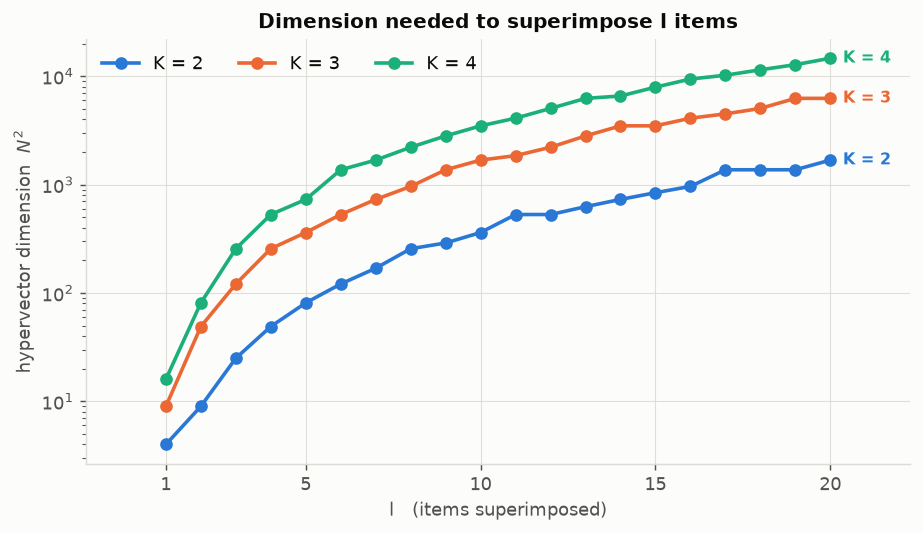

  l |        K=2        K=3        K=4
----------------------------------------
  1 |          4          9         16
  2 |          9         49         81
  4 |         49        256        529
  8 |        256        961       2209
 12 |        529       2209       5041
 16 |        961       4096       9409
 20 |       1681       6241      14641

Dimension grows like l^2: N must clear (K-1)(2l-1), and dim = N^2.


In [15]:
# --- the dimension cost of l, one line per K ----------------------------------------
KS = [2, 3, 4]
dims = {K: [dim_for(K, l) for l in LS] for K in KS}

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for i, K in enumerate(KS):
    ax.plot(LS, dims[K], color=PAL["series"][i], marker="o", label=f"K = {K}")
    ax.annotate(f"K = {K}", (LS[-1], dims[K][-1]), xytext=(7, 0),
                textcoords="offset points", color=PAL["series"][i],
                va="center", fontsize=9, fontweight="bold")
ax.set_yscale("log")
ax.set_xlabel("l   (items superimposed)")
ax.set_ylabel("hypervector dimension  $N^2$")
ax.set_title("Dimension needed to superimpose l items")
ax.set_xticks([1, 5, 10, 15, 20])
ax.margins(x=0.12)
ax.legend(loc="upper left", ncols=3)
fig.tight_layout()
fig.savefig("figures/dim_vs_l.png", bbox_inches="tight")
plt.show()

print(f"{'l':>3} | " + " ".join(f"{'K=' + str(K):>10}" for K in KS))
print("-" * 40)
for j, l in enumerate(LS):
    if l in (1, 2, 4, 8, 12, 16, 20):
        print(f"{l:>3} | " + " ".join(f"{dims[K][j]:>10}" for K in KS))
print("\nDimension grows like l^2: N must clear (K-1)(2l-1), and dim = N^2.")

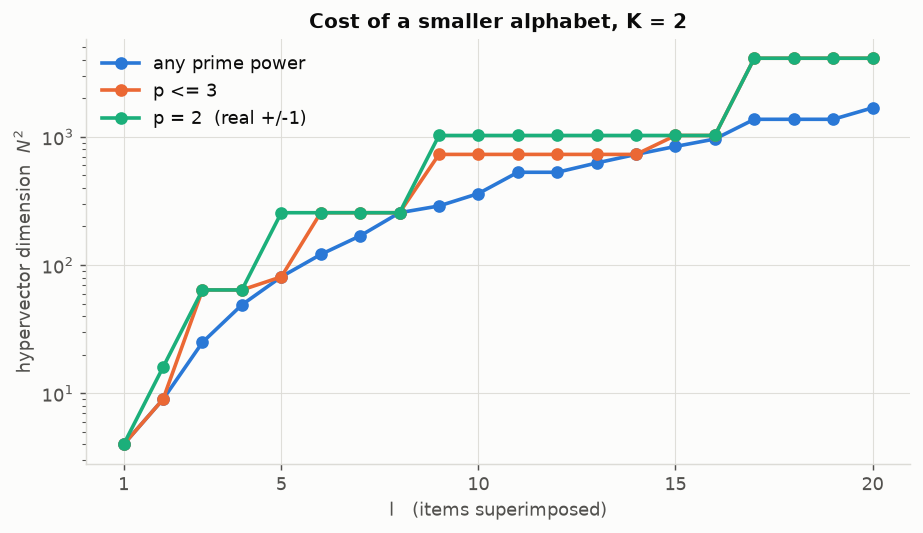

  l |    any prime power             p <= 3 p = 2  (real +/-1)
--------------------------------------------------------------
  2 |                  9                  9                 16
  4 |                 49                 64                 64
  8 |                256                256                256
 16 |                961               1024               1024
 20 |               1681               4096               4096

p = 2 pays in dimension (N rounds up to a power of two) and is repaid in
alphabet: two phase values, so hypervectors are real.


In [16]:
# --- what capping the alphabet costs, at K = 2 --------------------------------------
CAPS = [(None, "any prime power"), (3, "p <= 3"), (2, "p = 2  (real +/-1)")]
curves = {lab: [dim_for(2, l, max_p=cap) for l in LS] for cap, lab in CAPS}

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for i, (cap, lab) in enumerate(CAPS):
    ax.plot(LS, curves[lab], color=PAL["series"][i], marker="o", label=lab)
ax.set_yscale("log")
ax.set_xlabel("l   (items superimposed)")
ax.set_ylabel("hypervector dimension  $N^2$")
ax.set_title("Cost of a smaller alphabet, K = 2")
ax.set_xticks([1, 5, 10, 15, 20])
ax.legend(loc="upper left")
fig.tight_layout()
fig.savefig("figures/dim_vs_l_alphabet.png", bbox_inches="tight")
plt.show()

print(f"{'l':>3} | " + " ".join(f"{lab:>18}" for _, lab in CAPS))
print("-" * 62)
for j, l in enumerate(LS):
    if l in (2, 4, 8, 16, 20):
        print(f"{l:>3} | " + " ".join(f"{curves[lab][j]:>18}" for _, lab in CAPS))
print("\np = 2 pays in dimension (N rounds up to a power of two) and is repaid in")
print("alphabet: two phase values, so hypervectors are real.")

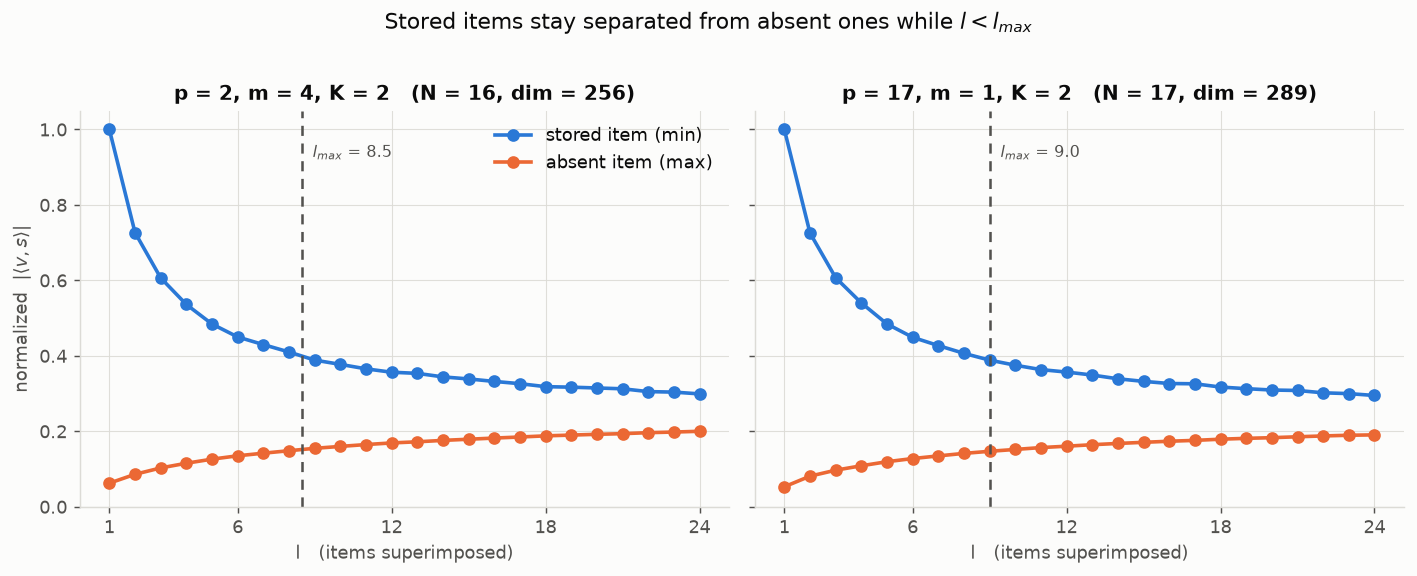


p=2 m=4 K=2  N=16  l_max=8.50
  l  stored(min)  absent(max)    margin
  1        1.000        0.062     0.938
  2        0.727        0.086     0.641
  4        0.536        0.115     0.421
  8        0.410        0.148     0.262
 12        0.357        0.169     0.187
 16        0.332        0.182     0.150
 20        0.315        0.192     0.123
 24        0.299        0.200     0.099

p=17 m=1 K=2  N=17  l_max=9.00
  l  stored(min)  absent(max)    margin
  1        1.000        0.053     0.947
  2        0.726        0.081     0.644
  4        0.540        0.109     0.432
  8        0.407        0.141     0.265
 12        0.357        0.160     0.197
 16        0.327        0.174     0.153
 20        0.309        0.183     0.126
 24        0.295        0.191     0.104


In [17]:
# --- measured separation as l grows -------------------------------------------------
def separation_sweep(p, m, K, ls, trials, seed):
    """Per l: mean min similarity of a stored item, mean max of an absent one."""
    tab = gf_tables(p, m)
    q, dim = p ** m, p ** (2 * m)
    size = q ** K
    rng = np.random.default_rng(seed)
    stored, absent = [], []
    for l in ls:
        lo, hi = [], []
        for _ in range(trials):
            idx = rng.choice(size, size=min(2 * l, size), replace=False)
            msgs = [[(int(i) // q ** k) % q for k in range(K)] for i in idx]
            V = np.array([histo_encode(u, p, m, tab) for u in msgs[:l]])
            W = np.array([histo_encode(u, p, m, tab) for u in msgs[l:]])
            s = V.sum(axis=0)
            denom = np.linalg.norm(s) * np.sqrt(dim)
            lo.append(np.abs(V.conj() @ s).min() / denom)
            hi.append(np.abs(W.conj() @ s).max() / denom)
        stored.append(np.mean(lo))
        absent.append(np.mean(hi))
    return np.array(stored), np.array(absent)


SWEEP_LS = list(range(1, 25))
CODES = [(2, 4, 2), (17, 1, 2)]        # N = 16 vs 17: same theory, alphabet 2 vs 17

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.3), sharey=True)
rows = []
for ax, (p, m, K) in zip(axes, CODES):
    N = p ** m
    st, ab = separation_sweep(p, m, K, SWEEP_LS, trials=10, seed=1)
    rows.append(((p, m, K, N), st, ab))
    ax.plot(SWEEP_LS, st, color=PAL["series"][0], marker="o", label="stored item (min)")
    ax.plot(SWEEP_LS, ab, color=PAL["series"][1], marker="o", label="absent item (max)")
    ax.axvline(l_max(N, K), color=PAL["ink2"], linestyle=(0, (4, 3)), linewidth=1.4)
    ax.annotate(f"$l_{{max}}$ = {l_max(N, K):.1f}", (l_max(N, K), 0.96),
                xytext=(6, 0), textcoords="offset points", color=PAL["ink2"],
                fontsize=9, va="top")
    ax.set_title(f"p = {p}, m = {m}, K = {K}   (N = {N}, dim = {p ** (2 * m)})")
    ax.set_xlabel("l   (items superimposed)")
    ax.set_xticks([1, 6, 12, 18, 24])
axes[0].set_ylabel("normalized  $|\\langle v, s \\rangle|$")
axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="upper right")
fig.suptitle("Stored items stay separated from absent ones while $l < l_{max}$", y=1.02)
fig.tight_layout()
fig.savefig("figures/separation_vs_l.png", bbox_inches="tight")
plt.show()

for (p, m, K, N), st, ab in rows:
    print(f"\np={p} m={m} K={K}  N={N}  l_max={l_max(N, K):.2f}")
    print(f"{'l':>3} {'stored(min)':>12} {'absent(max)':>12} {'margin':>9}")
    for j, l in enumerate(SWEEP_LS):
        if l in (1, 2, 4, 8, 12, 16, 20, 24):
            print(f"{l:>3} {st[j]:>12.3f} {ab[j]:>12.3f} {st[j] - ab[j]:>9.3f}")

# What the graphs are saying

## The first two: what $l$ costs you

Nothing subtle here --- they are the bound $N \ge (K-1)(2l-1)$ plotted on a log axis.
The single fact worth carrying away is that **dimension is quadratic in $l$**: since
$N$ grows linearly in $l$ and $\text{dim} = N^2$, doubling how many items you bundle
costs about **4x** the dimension. Naming more items, by contrast, is nearly free ---
$N^K$ grows so fast that vocabulary stops being the binding constraint almost
immediately.

Graph 2 prices the other axis. Forcing $p = 2$ (so that $\phi$ lands on $\{+1,-1\}$ and
hypervectors are real) means $N$ must round up to a power of two. At $l = 20$ that is
$N = 64$ instead of $N = 41$, and squaring turns a 1.6x increase in $N$ into 2.4x the
dimension. That is the whole cost of a binary alphabet.

## The third: a signal-to-noise plot

This one is worth slowing down on, because it is not a plot of a formula --- it is a
measurement, and it answers the only question that matters in practice: *after I add
$l$ items together, can I still tell what is in there?*

**The experiment.** Add $l$ hypervectors together into one bundle $s$. Now ask of some
candidate $v$, "is $v$ in $s$?", and answer it with a threshold on the normalised
overlap $|\langle v, s\rangle|$. Two things can go wrong, so the graph plots the worst
case of each:

- **Blue --- the weakest true positive.** Of the $l$ items genuinely in $s$, the one
  that shows up most faintly.
- **Orange --- the strongest false positive.** Of the items never added, the one that
  most resembles $s$ by accident.

**Blue above orange means the scheme works.** Any threshold drawn between the two curves
separates every real member from every non-member, with no errors. The *vertical gap* is
the safety margin, and it is the only thing the graph is really showing.

## Why the curves converge

Because every item you add is interference for every other item.

Think of a room of $l$ people talking at once, and you are trying to decide whether a
particular voice is present. Two effects work against you as $l$ grows. Each individual
voice is a smaller share of the total sound, so the genuine speakers get harder to hear
(blue falls). And the babble of everyone else grows louder, so it starts to sound like
voices that were never there (orange rises). Recognition works for exactly as long as
the quietest real speaker is still louder than the loudest phantom.

In algebra, probing with a stored item gives

$$\langle v_i, s\rangle = \underbrace{\langle v_i, v_i\rangle}_{\text{signal, fixed}}
  + \underbrace{\sum_{j \ne i} \langle v_i, v_j\rangle}_{\text{interference, grows with } l}$$

while probing with an absent item has **no signal term at all** --- only interference.
That asymmetry is the entire basis of the readout. The signal stays the same size no
matter how many items you add; the interference does not; and the bundle's norm keeps
growing, which shrinks everything once normalised. Hence blue down, orange up.

## What $l_{\max}$ actually marks

The dashed line. Note that **nothing visibly happens there** --- and that is the point.
$l_{\max}$ is where the theory stops *promising* the gap stays open, not where the gap
closes. At $l_{\max} = 8.5$ the measured margin is still about $0.26$, and the curves do
not meet anywhere in the plotted range. So the bound is roughly 2x conservative: a safe
operating point, not a cliff edge.

## Why two panels

Left is $p = 2, m = 4$: $N = 16$, and every coordinate is $\pm 1$. Right is
$p = 17, m = 1$: $N = 17$, and every coordinate is one of seventeen complex phases.
Utterly different representations --- and the curves agree to within about $0.01$ at
every $l$.

That is the notebook's central claim, measured rather than asserted: the behaviour
depends on $N$ alone, not on how $N$ splits into $p^m$. Choose the factorisation for
whatever reason you like --- cheap hardware, real arithmetic, tight fit --- and the
coding theory will not notice.